In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import textwrap

BASE           = '/content/drive/MyDrive/02_NandiSeedRecommender2'
OUT_DIR        = os.path.join(BASE, 'WardAggregatedData')
FINAL_DIR      = os.path.join(BASE, 'Final_Outputs')
SEED_XLSX_PATH = os.path.join(BASE, 'Seed_Data/KenyaSeedWebScrape.xlsx')

# ---- Load data ----
wards_gdf = gpd.read_file(os.path.join(OUT_DIR, 'Nandi_Ward_Aggregation.geojson'))
county    = gpd.read_file(os.path.join(BASE, 'NandiCounties/counties.shp'))
nandi     = county[county['COUNTY_NAM'] == 'NANDI']

try:
    nandi_union = nandi.union_all()
except AttributeError:
    nandi_union = nandi.geometry.unary_union

wards_gdf = wards_gdf[wards_gdf.geometry.centroid.within(nandi_union)].copy()
name_col  = next((c for c in wards_gdf.columns if 'NAME' in c.upper() or 'WARD' in c.upper()), None)
if name_col:
    wards_gdf = wards_gdf[~wards_gdf[name_col].str.upper().isin(['MANDA-SHIVANGA'])]

if os.path.exists(SEED_XLSX_PATH):
    seed_df = pd.read_excel(SEED_XLSX_PATH, engine='openpyxl')
    seed_df.columns = seed_df.columns.str.strip()
else:
    seed_df = pd.DataFrame()

json_path = os.path.join(FINAL_DIR, 'County_Averages.json')
if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        county_ref_full = json.load(f)
else:
    county_ref_full = {}

# ============================================================
# HELPERS
# ============================================================

RAW_KEY_MAP = {'rain': 'mean_season_rain', 'temp': 'mean_temp', 'rh': 'rh_dev'}

# ---- OFRA Rift Valley Upper coefficients (Table 7.2g, Kibunja et al. 2017) ----
OFRA_RV_UPPER = {
    'HP': {'N': {'b': 2.640, 'c': 0.903}, 'P': {'b': 0.738, 'c': 0.904}},
    'LP': {'N': {'b': 0.200, 'c': 0.886}, 'P': {'b': 0.792, 'c': 0.990}},
}

def mitscherlich(b, c, r):
    if r <= 0: return 0.0
    return b * (1 - c ** r)

def get_fert_nutrient_rates(ph, tn, p_ppm):
    if ph < 5.5:
        if tn < 0.2 and p_ppm < 15:   return 39, 20
        elif tn < 0.2:                  return 39,  0
        elif p_ppm <= 15:               return  0, 20
        else:                           return  0,  0
    else:
        if tn < 0.2 and p_ppm < 15:   return 39, 20
        elif tn < 0.2:                  return 39,  0
        elif p_ppm <= 15:               return  0, 20
        else:                           return  0,  0

def add_yield_estimates(top_seeds, suit_mu, ph, tn, p_ppm):
    if top_seeds.empty:
        return top_seeds

    if np.isnan(suit_mu):
        lo_f, hi_f = 0.0, 0.4
    else:
        s = suit_mu * 100
        if   s >= 85: lo_f, hi_f = 0.85, 1.00
        elif s >= 60: lo_f, hi_f = 0.60, 0.85
        elif s >= 40: lo_f, hi_f = 0.40, 0.60
        else:         lo_f, hi_f = 0.00, 0.40

    has_soil = not any(np.isnan(v) for v in [ph, tn, p_ppm])
    if has_soil:
        n_rate, p_rate = get_fert_nutrient_rates(ph, tn, p_ppm)

    rows = []
    for _, r in top_seeds.iterrows():
        r = r.copy()
        py = pd.to_numeric(r['Potential yield (t/Ha)'], errors='coerce')

        if pd.isna(py):
            r['Expected Yield without Fertiliser (t/Ha)'] = 'N/A'
            r['Expected Yield with Fertiliser (t/Ha)']    = 'N/A'
        else:
            yno_lo = round(py * lo_f, 2)
            yno_hi = round(py * hi_f, 2)
            r['Expected Yield without Fertiliser (t/Ha)'] = f"{yno_lo} - {yno_hi}"

            if has_soil:
                coeff     = OFRA_RV_UPPER['HP'] if py >= 3.0 else OFRA_RV_UPPER['LP']
                n_inc     = mitscherlich(coeff['N']['b'], coeff['N']['c'], n_rate)
                p_inc     = mitscherlich(coeff['P']['b'], coeff['P']['c'], p_rate)
                total_inc = round(n_inc + p_inc, 3)
                yw_lo     = min(round(yno_lo + total_inc, 2), py)
                yw_hi     = min(round(yno_hi + total_inc, 2), py)
                r['Expected Yield with Fertiliser (t/Ha)'] = str(yw_hi) if yw_lo == yw_hi else f"{yw_lo} - {yw_hi}"
            else:
                r['Expected Yield with Fertiliser (t/Ha)'] = 'N/A (no soil data)'

        rows.append(r)

    return pd.DataFrame(rows, columns=list(top_seeds.columns) + [
        'Expected Yield without Fertiliser (t/Ha)',
        'Expected Yield with Fertiliser (t/Ha)',
    ])


def get_suitability_label(suit_score):
    if np.isnan(suit_score):  return "Unknown"
    if suit_score > 0.75:     return "Very Suitable"
    elif suit_score > 0.50:   return "Moderately Suitable"
    elif suit_score > 0.25:   return "Marginally Suitable"
    else:                     return "Not Suitable"

# ============================================================
# SEED SCORING
# ============================================================

def score_seeds_for_ward(seed_df, elevation, precip, max_temp, min_temp,
                         drought_prob, flood_prob, county_avg_drought, county_avg_flood):
    if seed_df.empty:
        return pd.DataFrame()

    eligible = seed_df[
        (seed_df['Elevation Min'] <= elevation) &
        (seed_df['Elevation Max'] >= elevation)
    ].copy()

    if eligible.empty:
        return pd.DataFrame()

    results = []
    for _, row in eligible.iterrows():
        score      = 0.0
        total_poss = 0.0

        total_poss += 0.47
        try:
            if row['Precipitation Min'] <= precip <= row['Precipitation Max']:
                score += 0.47
        except:
            pass

        total_poss += 0.13
        try:
            elev_min   = row['Elevation Min']
            elev_max   = row['Elevation Max']
            midpoint   = (elev_min + elev_max) / 2
            half_range = (elev_max - elev_min) / 2
            if half_range > 0:
                centrality = 1 - (abs(elevation - midpoint) / half_range)
                score += 0.13 * max(centrality, 0)
            else:
                score += 0.13
        except:
            pass

        if not np.isnan(flood_prob) and not np.isnan(county_avg_flood):
            if flood_prob > county_avg_flood:
                total_poss += 0.47
                if row.get('Flood-Resistant', 0) == 1:
                    score += 0.47

        if not np.isnan(drought_prob) and not np.isnan(county_avg_drought):
            if drought_prob > county_avg_drought:
                total_poss += 0.13
                if row.get('Moisture-Stress Tolerant', 0) == 1:
                    score += 0.13

        if not np.isnan(max_temp) and max_temp > 35:
            total_poss += 0.13
            if row.get('Heat Tolerant', 0) == 1:
                score += 0.13

        if not np.isnan(min_temp) and min_temp < 10:
            total_poss += 0.13
            if row.get('Cold Tolerant', 0) == 1:
                score += 0.13

        weighted_score = (score / total_poss) if total_poss > 0 else 0.0

        results.append({
            'Variety':                row['Variety'],
            'Score':                  round(weighted_score * 100, 1),
            'Time to Maturity':       row.get('Time to Maturity', 'N/A'),
            'Potential yield (t/Ha)': row.get('Potential yield (t/Ha)', 'N/A'),
            'Key Attributes':         row.get('Key Attributes', 'N/A'),
        })

    out = pd.DataFrame(results)
    out = out[out['Score'] > 0]

    if out.empty:
        return pd.DataFrame()

    out['YieldNumeric'] = pd.to_numeric(out['Potential yield (t/Ha)'], errors='coerce')
    out = out.sort_values(['Score', 'YieldNumeric'], ascending=[False, False])
    return out.drop(columns='YieldNumeric').head(3)

# ============================================================
# FERTILISER TEXT LOGIC
# ============================================================

def get_fertiliser_text(ph, total_nitrogen, phosphorus_ppm, zinc_score, potassium_cmol):
    lines = []

    if ph < 5.5:
        if total_nitrogen < 0.2:
            if phosphorus_ppm < 15:
                lines.append(
                    "The soil in your area is acidic and low in phosphorus and nitrogen. "
                    "For optimal maize growth, it is recommended to apply MEA Mazao (250 kg/ha) "
                    "followed by Manvuno top-dressing (185 kg/ha) to increase nitrogen and phosphorus "
                    "levels while reducing acidity. Alternatively, apply 100 kg/ha of DAP followed by "
                    "81 kg/ha of CAN approximately six weeks after planting. "
                    "Please note that if you are intercropping cereal and beans, you should increase "
                    "DAP by 17 kg/ac; if you are intercropping cereal and legumes, increase DAP by 27 kg/ac."
                )
            else:
                lines.append(
                    "The soil in your area is acidic and low in nitrogen, but it is rich in phosphorus. "
                    "No phosphorus fertiliser is needed. For optimal maize growth, it is recommended to "
                    "apply 150 kg/ha of CAN to increase nitrogen concentration and reduce acidity."
                )
        else:
            if phosphorus_ppm > 15:
                lines.append(
                    "The soil in your area is high in phosphorus and nitrogen, but it is acidic. "
                    "For optimal maize growth, liming is recommended to reduce acidity."
                )
            else:
                lines.append(
                    "The soil in your area is high in nitrogen, but it is acidic and low in phosphorus. "
                    "For optimal maize growth, it is recommended to apply 100 kg/ha of TSP at planting "
                    "to increase phosphorus concentration without increasing soil acidity. "
                    "Liming may also be beneficial. "
                    "Please note that if you are intercropping cereal and beans, you should increase "
                    "TSP by 17 kg/ac; if you are intercropping cereal and legumes, increase TSP by 27 kg/ac."
                )
    else:
        if total_nitrogen < 0.2:
            if phosphorus_ppm < 15:
                lines.append(
                    "The soil in your area is low in phosphorus and nitrogen, but the acidity levels "
                    "are good. For optimal maize growth, it is recommended to apply 100 kg/ha of DAP "
                    "at planting. Side-dress with the most cost-effective nitrogen source, 46 kg/ha of "
                    "Urea, six weeks after planting. This will increase both phosphorus and nitrogen "
                    "concentrations. "
                    "Please note that if you are intercropping cereal and beans, you should increase "
                    "DAP by 17 kg/ac; if you are intercropping cereal and legumes, increase DAP by "
                    "27 kg/ac and reduce urea by 22 kg/ac."
                )
            else:
                lines.append(
                    "The soil in your area is low in nitrogen, but the phosphorus levels and acidity "
                    "are good. For optimal maize growth, side-dressing 85 kg/ha of Urea is recommended "
                    "to meet the nitrogen requirement. No phosphorus or liming is required. "
                    "Please note that if you are intercropping cereal and legumes, it is best to reduce "
                    "urea by 22 kg/ac."
                )
        else:
            if phosphorus_ppm > 15:
                lines.append(
                    "The soil in your area is high in phosphorus and nitrogen, and has optimal acidity "
                    "for maize growth. No nitrogen or phosphorus-based fertilisers are required, and "
                    "liming is not necessary."
                )
            else:
                lines.append(
                    "The soil in your area is high in nitrogen and has good acidity for maize growth, "
                    "but it is low in phosphorus. For optimal maize growth, it is recommended to apply "
                    "100 kg/ha of TSP at planting to increase phosphorus concentration without increasing "
                    "soil acidity. Liming may also be beneficial. "
                    "Please note that if you are intercropping cereal and beans, you should increase "
                    "TSP by 17 kg/ac; if you are intercropping cereal and legumes, increase TSP by 27 kg/ac."
                )

    if not np.isnan(zinc_score) and zinc_score < 1.0:
        lines.append(
            "Your soil may be deficient in zinc and could benefit from zinc sulfate fertiliser. "
            "A zinc soil test is recommended."
        )

    if not np.isnan(potassium_cmol) and potassium_cmol < 0.256:
        lines.append(
            "Your soil is deficient in potassium. For optimal maize growth, band application of "
            "50 kg/ha of potassium chloride is recommended."
        )

    lines.append(
        "If a field extension officer is available, we recommend consulting them to refine "
        "these guidelines for your specific plot."
    )

    return lines

# ============================================================
# CORE DATA EXTRACTION
# ============================================================

def extract_season_data(ward, season, county_ref):
    pfx_fact     = 'LR_Fact' if 'Long' in season else 'SR_Fact'
    pfx_raw      = 'LR_Raw'  if 'Long' in season else 'SR_Raw'
    pfx_main     = 'Main'
    season_label = 'Long Rains' if 'Long' in season else 'Short Rains'
    planting     = "March 25 to April 20" if 'Long' in season else "October 25 to November 15"

    def raw(var):
        rk = RAW_KEY_MAP.get(var, var)
        return ward.get(f'{pfx_raw}_{rk}_raw', np.nan)

    suit_mu    = ward.get(f'{pfx_main}_Suit_Mean_{season}', np.nan)
    suit_std   = ward.get(f'{pfx_main}_Suit_Std_{season}', np.nan)
    suit_label = get_suitability_label(suit_mu)
    suit_pct   = f"{suit_mu*100:.1f}" if not np.isnan(suit_mu) else "N/A"

    elev_col   = next((c for c in ward.index if 'elev' in c.lower()), None)
    elev_val   = ward[elev_col] if elev_col else np.nan
    precip_val = raw('rain')
    mean_temp  = ward.get(f'{pfx_raw}_mean_temp_raw', np.nan)
    max_temp   = ward.get(f'{pfx_raw}_max_temp_raw',  np.nan)
    min_temp   = ward.get(f'{pfx_raw}_min_temp_raw',  np.nan)

    drought_prob       = ward.get(f'{pfx_fact}_prob_drought_mean', np.nan)
    flood_prob         = ward.get(f'{pfx_fact}_prob_flood_mean',   np.nan)
    county_avg_drought = county_ref.get('scores', {}).get('prob_drought', np.nan)
    county_avg_flood   = county_ref.get('scores', {}).get('prob_flood',   np.nan)

    ph_val   = raw('ph')
    tn_val   = raw('total_nitrogen')
    p_val    = raw('phosphorus')
    k_val    = raw('potassium')
    zn_score = ward.get(f'{pfx_fact}_zinc_mean', np.nan)

    top_seeds = score_seeds_for_ward(
        seed_df,
        elevation=elev_val   if not np.isnan(elev_val)   else 1500,
        precip=precip_val    if not np.isnan(precip_val) else 600,
        max_temp=max_temp,   min_temp=min_temp,
        drought_prob=drought_prob,         flood_prob=flood_prob,
        county_avg_drought=county_avg_drought, county_avg_flood=county_avg_flood,
    )

    top_seeds = add_yield_estimates(top_seeds, suit_mu, ph_val, tn_val, p_val)

    fert_lines = None
    if not any(np.isnan(v) for v in [ph_val, tn_val, p_val]):
        fert_lines = get_fertiliser_text(ph_val, tn_val, p_val, zn_score, k_val)

    return {
        'season_label':  season_label,
        'planting':      planting,
        'suit_mu':       suit_mu,
        'suit_std':      suit_std,
        'suit_pct':      suit_pct,
        'suit_label':    suit_label,
        'elev_val':      elev_val,
        'precip_val':    precip_val,
        'mean_temp':     mean_temp,
        'max_temp':      max_temp,
        'min_temp':      min_temp,
        'ph_val':        ph_val,
        'tn_val':        tn_val,
        'p_val':         p_val,
        'k_val':         k_val,
        'zn_score':      zn_score,
        'drought_prob':  drought_prob,
        'flood_prob':    flood_prob,
        'top_seeds':     top_seeds,
        'fert_lines':    fert_lines,
    }

# ============================================================
# PRINT REPORT (Document 4 - farmer facing, unchanged)
# ============================================================

def print_season_block(d, W):
    sl = d['season_label']

    elev_str  = f"{d['elev_val']:.0f} m"    if not np.isnan(d['elev_val'])   else "N/A"
    rain_str  = f"{d['precip_val']:.0f} mm"  if not np.isnan(d['precip_val']) else "N/A"
    meant_str = f"{d['mean_temp']:.1f} °C"   if not np.isnan(d['mean_temp'])  else "N/A"
    maxt_str  = f"{d['max_temp']:.1f} °C"    if not np.isnan(d['max_temp'])   else "N/A"
    ph_str    = f"{d['ph_val']:.2f}"          if not np.isnan(d['ph_val'])     else "N/A"
    tn_str    = f"{d['tn_val']:.3f} %"        if not np.isnan(d['tn_val'])     else "N/A"
    p_str     = f"{d['p_val']:.1f} mg/kg"     if not np.isnan(d['p_val'])      else "N/A"

    print(f"\n{'─'*W}")
    print(f" FOR THE {sl.upper()} SEASON:")
    print(f"{'─'*W}")
    print(f"\nThe conditions in your area are {d['suit_pct']}% ({d['suit_label']}) suitable for "
          f"maize growth, based on the local soil, weather conditions and terrain.")
    print(f"Elevation: {elev_str}  |  Rainfall: {rain_str}  |  Mean Temperature: {meant_str}  |  "
          f"Max Temperature: {maxt_str}  |  pH: {ph_str}  |  Nitrogen: {tn_str}  |  "
          f"Phosphorus: {p_str}\n")

    print("Below are the top 3 recommended seed varieties based on your location.\n")
    if not d['top_seeds'].empty:
        print(f"  {'Variety':<14} {'Score':>7}%  {'Maturity':<18} "
              f"{'Potential Yield (t/ha)':>22}  {'without Fertiliser':>20}  {'with Fertiliser':>20}  Key Attributes")
        print(f"  {'─'*140}")
        for _, r in d['top_seeds'].iterrows():
            print(f"  {r['Variety']:<14} {r['Score']:>7.1f}%  "
                  f"{str(r['Time to Maturity']):<18} "
                  f"{str(r['Potential yield (t/Ha)']):>22}  "
                  f"{str(r['Expected Yield without Fertiliser (t/Ha)']):>20}  "
                  f"{str(r['Expected Yield with Fertiliser (t/Ha)']):>20}  "
                  f"{str(r['Key Attributes'])}")
    else:
        print("  No seed varieties matched the elevation criteria for this ward.")

    print(f"\nFor the {sl} season, the optimal planting time for maize in your "
          f"region is {d['planting']}.\n")

    print("Below are fertiliser recommendations based on the soil properties in your location. "
          "Nitrogen-based fertiliser can improve yields by an average of 2.634 t/ha in your region, "
          "while phosphorus-based fertilisers improve yields by 0.640 t/ha.\n")

    if d['fert_lines'] is None:
        print("  Insufficient soil data to generate fertiliser recommendation for this ward.\n")
    else:
        for line in d['fert_lines']:
            wrapped = textwrap.fill(line, width=W - 4, subsequent_indent='  ')
            print(f"  {wrapped}\n")

    if not np.isnan(d['drought_prob']) and d['drought_prob'] > 0.15:
        print(f"⚠  Warning: During the {sl} season, your area has a historically high "
              f"drought risk ({d['drought_prob']*100:.1f}% of seasons). Consider staged fertiliser "
              f"application and prioritise drought-tolerant seed varieties.\n")

    if not np.isnan(d['flood_prob']) and d['flood_prob'] > 0.15:
        print(f"⚠  Warning: During the {sl} season, your area has a historically high "
              f"flood risk ({d['flood_prob']*100:.1f}% of seasons). Avoid basal fertiliser "
              f"application immediately before forecast heavy rainfall.\n")

    if not np.isnan(d['suit_std']):                                                        # ADD
        print(f"The uncertainty of the suitability prediction for this ward is ±{d['suit_std']*100:.1f}%.\n")  # ADD


def get_ward_report(ward_name):
    ward_row = wards_gdf[wards_gdf[name_col].str.upper() == ward_name.upper()]
    if ward_row.empty:
        print(f"Ward '{ward_name}' not found.")
        print("Available:", sorted(wards_gdf[name_col].tolist()))
        return
    ward = ward_row.iloc[0]
    W    = 115

    print(f"\n{'='*W}")
    print(f"  NANDI PRECISION AGRICULTURE REPORT  |  {ward_name.upper()}")
    print(f"{'='*W}")

    for season in ['LongRains', 'ShortRains']:
        county_ref = county_ref_full.get(season, {'scores': {}, 'raw': {}})
        d = extract_season_data(ward, season, county_ref)
        print_season_block(d, W)

    print(f"\n{'='*W}\n")

# ============================================================
# CSV EXPORT (full text, one row per ward)
# ============================================================

def get_ward_csv_row(ward_name):
    ward_row = wards_gdf[wards_gdf[name_col].str.upper() == ward_name.upper()]
    if ward_row.empty:
        return None
    ward     = ward_row.iloc[0]
    row_data = {'Ward': ward_name}

    for season in ['LongRains', 'ShortRains']:
        county_ref = county_ref_full.get(season, {'scores': {}, 'raw': {}})
        d  = extract_season_data(ward, season, county_ref)
        s  = 'LR' if 'Long' in season else 'SR'
        sl = d['season_label']

        elev_str  = f"{d['elev_val']:.0f} m"    if not np.isnan(d['elev_val'])   else "N/A"
        rain_str  = f"{d['precip_val']:.0f} mm"  if not np.isnan(d['precip_val']) else "N/A"
        meant_str = f"{d['mean_temp']:.1f} C"    if not np.isnan(d['mean_temp'])  else "N/A"
        maxt_str  = f"{d['max_temp']:.1f} C"     if not np.isnan(d['max_temp'])   else "N/A"
        ph_str    = f"{d['ph_val']:.2f}"          if not np.isnan(d['ph_val'])     else "N/A"
        tn_str    = f"{d['tn_val']:.3f}%"         if not np.isnan(d['tn_val'])     else "N/A"
        p_str     = f"{d['p_val']:.1f} mg/kg"     if not np.isnan(d['p_val'])      else "N/A"

        row_data[f'{s}_Suitability'] = (
            f"The conditions in your area are {d['suit_pct']}% ({d['suit_label']}) suitable for maize growth, "
            f"based on the local soil, weather conditions and terrain. "
            f"Elevation: {elev_str} | Rainfall: {rain_str} | Mean Temp: {meant_str} | "
            f"Max Temp: {maxt_str} | pH: {ph_str} | Nitrogen: {tn_str} | Phosphorus: {p_str}"
        )

        if not d['top_seeds'].empty:
            seed_lines = []
            for _, r in d['top_seeds'].iterrows():
                seed_lines.append(
                    f"{r['Variety']} (Score: {r['Score']}% | "
                    f"Potential Yield: {r['Potential yield (t/Ha)']} t/Ha | "
                    f"Expected w/o Fertiliser: {r['Expected Yield without Fertiliser (t/Ha)']} t/Ha | "
                    f"Expected w/ Fertiliser: {r['Expected Yield with Fertiliser (t/Ha)']} t/Ha | "
                    f"Maturity: {r['Time to Maturity']} | {r['Key Attributes']})"
                )
            row_data[f'{s}_Seeds'] = "Top recommended seed varieties: " + " | ".join(seed_lines)
        else:
            row_data[f'{s}_Seeds'] = "No seed varieties matched the elevation criteria for this ward."

        row_data[f'{s}_Planting_Window'] = (
            f"For the {sl} season, the optimal planting time for maize in your region is {d['planting']}."
        )

        if d['fert_lines'] is None:
            row_data[f'{s}_Fertiliser'] = "Insufficient soil data to generate fertiliser recommendation."
        else:
            fert_intro = (
                "Nitrogen-based fertiliser can improve yields by an average of 2.634 t/ha in your region, "
                "while phosphorus-based fertilisers improve yields by 0.640 t/ha. "
            )
            row_data[f'{s}_Fertiliser'] = fert_intro + " ".join(d['fert_lines'])

        warnings = []
        if not np.isnan(d['drought_prob']) and d['drought_prob'] > 0.15:
            warnings.append(
                f"WARNING: During the {sl} season, your area has a historically high drought risk "
                f"({d['drought_prob']*100:.1f}% of seasons). Consider staged fertiliser application "
                f"and prioritise drought-tolerant seed varieties."
            )
        if not np.isnan(d['flood_prob']) and d['flood_prob'] > 0.15:
            warnings.append(
                f"WARNING: During the {sl} season, your area has a historically high flood risk "
                f"({d['flood_prob']*100:.1f}% of seasons). Avoid basal fertiliser application "
                f"immediately before forecast heavy rainfall."
            )
        row_data[f'{s}_Risk_Warnings'] = " | ".join(warnings) if warnings else ""
        row_data[f'{s}_Suitability_Uncertainty'] = f"±{d['suit_std']*100:.1f}%" if not np.isnan(d['suit_std']) else "N/A"

    return row_data


def export_all_wards_csv(out_path=None):
    if out_path is None:
        out_path = os.path.join(OUT_DIR, 'Nandi_Ward_Recommendations.csv')

    ward_names = sorted(wards_gdf[name_col].tolist())
    records    = []
    for ward_name in ward_names:
        print(f"  Processing {ward_name}...")
        data = get_ward_csv_row(ward_name)
        if data:
            records.append(data)

    df = pd.DataFrame(records)
    df.to_csv(out_path, index=False)
    print(f"\nSaved {len(records)} wards to {out_path}")
    return df

# ============================================================
# SMS EXPORT
# ============================================================

def build_sms_messages(ward_name):
    ward_row = wards_gdf[wards_gdf[name_col].str.upper() == ward_name.upper()]
    if ward_row.empty:
        return {}
    ward   = ward_row.iloc[0]
    output = {}

    for season in ['LongRains', 'ShortRains']:
        county_ref = county_ref_full.get(season, {'scores': {}, 'raw': {}})
        d        = extract_season_data(ward, season, county_ref)
        sl       = d['season_label'].upper()
        messages = []

        elev_str  = f"{d['elev_val']:.0f}m"    if not np.isnan(d['elev_val'])   else "N/A"
        rain_str  = f"{d['precip_val']:.0f}mm"  if not np.isnan(d['precip_val']) else "N/A"
        meant_str = f"{d['mean_temp']:.1f}C"    if not np.isnan(d['mean_temp'])  else "N/A"
        maxt_str  = f"{d['max_temp']:.1f}C"     if not np.isnan(d['max_temp'])   else "N/A"
        ph_str    = f"{d['ph_val']:.2f}"         if not np.isnan(d['ph_val'])     else "N/A"
        tn_str    = f"{d['tn_val']:.3f}%"        if not np.isnan(d['tn_val'])     else "N/A"
        p_str     = f"{d['p_val']:.1f}mg/kg"     if not np.isnan(d['p_val'])      else "N/A"

        messages.append(
            f"{ward_name.upper()} - {sl}\n"
            f"Suitability: {d['suit_pct']}% ({d['suit_label']})\n"
            f"Elev: {elev_str} | Rain: {rain_str} | Temp: {meant_str} max {maxt_str}\n"
            f"pH: {ph_str} | N: {tn_str} | P: {p_str}"
        )

        if not d['top_seeds'].empty:
            seed_lines = []
            for i, (_, r) in enumerate(d['top_seeds'].iterrows(), 1):
                seed_lines.append(
                    f"{i}. {r['Variety']} ({r['Score']}%) - "
                    f"Pot: {r['Potential yield (t/Ha)']}t/ha | "
                    f"w/o fert: {r['Expected Yield without Fertiliser (t/Ha)']} | "
                    f"w/ fert: {r['Expected Yield with Fertiliser (t/Ha)']}. "
                    f"{r['Time to Maturity']}. {r['Key Attributes']}"
                )
            messages.append("SEEDS\n" + "\n".join(seed_lines))
        else:
            messages.append("SEEDS\nNo varieties matched your elevation.")

        messages.append(f"PLANTING\n{d['season_label']}: plant {d['planting']}")

        if d['fert_lines'] is None:
            messages.append("FERTILISER\nInsufficient soil data.")
        else:
            fert_intro = "Nitrogen fertiliser improves yield by 2.6t/ha in your region, and phosphorus by 0.6t/ha. "
            fert_body  = " ".join(d['fert_lines'])
            replacements = [
                ("For optimal maize growth, it is recommended to apply", "Apply"),
                ("For optimal maize growth, it is recommended to",       ""),
                ("it is recommended to",                                  ""),
                ("approximately six weeks after planting",               "6 weeks after planting"),
                ("Please note that if you are intercropping",            "Intercrop"),
                ("you should increase",                                   "increase"),
                ("If a field extension officer is available, we recommend consulting them to refine these guidelines for your specific plot.",
                 "Consult extension officer to refine."),
                ("could benefit from zinc sulfate fertiliser. A zinc soil test is recommended.",
                 "Zinc sulfate may help. Soil test recommended."),
                ("band application of",  "band-apply"),
                ("it is best to reduce", "reduce"),
            ]
            for old, new in replacements:
                fert_body = fert_body.replace(old, new)
            messages.append(f"FERTILISER\n{fert_intro}{fert_body.strip()}")

        warnings = []
        if not np.isnan(d['drought_prob']) and d['drought_prob'] > 0.15:
            warnings.append(
                f"DROUGHT RISK: {d['drought_prob']*100:.1f}% of seasons. "
                f"Use staged fertiliser. Prioritise drought-tolerant seeds."
            )
        if not np.isnan(d['flood_prob']) and d['flood_prob'] > 0.15:
            warnings.append(
                f"FLOOD RISK: {d['flood_prob']*100:.1f}% of seasons. "
                f"Avoid basal fertiliser before heavy rain."
            )
        if warnings:
            messages.append("WARNINGS\n" + "\n".join(warnings))

        total = len(messages)
        output[season] = [f"MSG {i+1}/{total} - {m}" for i, m in enumerate(messages)]

    return output


def print_sms_preview(ward_name):
    sms = build_sms_messages(ward_name)
    for season, msgs in sms.items():
        season_label = 'Long Rains' if 'Long' in season else 'Short Rains'
        print(f"\n{'='*60}")
        print(f"  {season_label.upper()}")
        print(f"{'='*60}")
        for msg in msgs:
            print(f"\n┌{'─'*58}┐")
            for line in msg.split('\n'):
                for chunk in textwrap.wrap(line, width=56) or ['']:
                    print(f"│ {chunk:<56} │")
            print(f"└{'─'*58}┘")
            print(f"  {len(msg)} chars")


def export_sms_csv(out_path=None):
    if out_path is None:
        out_path = os.path.join(OUT_DIR, 'Nandi_Ward_SMS.csv')

    ward_names = sorted(wards_gdf[name_col].tolist())
    records    = []

    for ward_name in ward_names:
        print(f"  Processing {ward_name}...")
        sms = build_sms_messages(ward_name)
        row = {'Ward': ward_name}
        for season, msgs in sms.items():
            pfx = 'LR' if 'Long' in season else 'SR'
            for i, msg in enumerate(msgs, 1):
                row[f'{pfx}_MSG{i}'] = msg
        records.append(row)

    df = pd.DataFrame(records)
    df.to_csv(out_path, index=False)
    print(f"\nSaved {len(records)} wards to {out_path}")
    return df

# ============================================================
# DETAILED FACTORS TABLE (Document 5 - variable table only)
# ============================================================

UNITS = {
    'ph': '', 'total_nitrogen': '%', 'phosphorus': 'mg/kg', 'potassium': 'cmol/kg',
    'calcium': 'cmol/kg', 'magnesium': 'cmol/kg', 'organic_carbon': '%',
    'ecec': 'cmol/kg', 'zinc': 'mg/kg', 'iron': 'mg/kg', 'clay_content': '%',
    'slope': '%', 'rain': 'mm', 'temp': '°C', 'rh': '%', 'bedrock_depth': 'cm',
    'elevation': 'm', 'stone_content': '%', 'cec_apparent': 'cmol/kg', 'texture': '',
    'min_temp': '°C', 'max_temp': '°C', 'germin_temp': '°C',
    'rh_dev': '%', 'rh_mat': '%',
    'prec_month1': 'mm', 'prec_month2': 'mm', 'prec_month3': 'mm', 'prec_month4': 'mm',
    'mean_season_rain': 'mm', 'mean_temp': '°C',
}

TEXTURE_NAMES = {
    1: 'Clay', 2: 'Silty Clay', 3: 'Silty Clay Loam', 4: 'Sandy Clay',
    5: 'Sandy Clay Loam', 6: 'Clay Loam', 7: 'Silt', 8: 'Silt Loam',
    9: 'Loam', 10: 'Sandy Loam', 11: 'Loamy Sand', 12: 'Sand',
}

SOIL_VARS    = {'ph', 'total_nitrogen', 'phosphorus', 'potassium', 'calcium', 'magnesium',
                'organic_carbon', 'ecec', 'cec_apparent', 'zinc', 'iron', 'clay_content'}
CLIMATE_VARS = {'rain', 'temp', 'rh', 'min_temp', 'max_temp', 'germin_temp',
                'rh_dev', 'rh_mat', 'prec_month1', 'prec_month2', 'prec_month3', 'prec_month4'}
TEMP_ORDER   = ['temp', 'min_temp', 'max_temp', 'germin_temp']
RAIN_ORDER   = ['rain', 'prec_month1', 'prec_month2', 'prec_month3', 'prec_month4']
RH_ORDER     = ['rh', 'rh_mat', 'rh_dev']

RISK_LABELS  = ['Cold Risk', 'Heat Risk', 'Drought Risk', 'Flood Risk', 'Overall Failure']
RISK_KEY_MAP = {
    'Cold Risk':       'prob_cold',
    'Heat Risk':       'prob_heat',
    'Drought Risk':    'prob_drought',
    'Flood Risk':      'prob_flood',
    'Overall Failure': 'prob_overall_fail',
}


def _build_factors_data(ward, season, county_ref):
    """
    Extracts all variable table data for one ward/season.
    Returns (risk_data, soil_list, climate_list, phys_list).
    """
    pfx_fact = 'LR_Fact' if 'Long' in season else 'SR_Fact'
    pfx_raw  = 'LR_Raw'  if 'Long' in season else 'SR_Raw'

    def get_val(var, kind='score'):
        if kind == 'score': return ward.get(f'{pfx_fact}_{var}_mean', np.nan)
        elif kind == 'unc': return ward.get(f'{pfx_fact}_{var}_std',  np.nan)
        elif kind == 'raw':
            rk = RAW_KEY_MAP.get(var, var)
            return ward.get(f'{pfx_raw}_{rk}_raw', np.nan)

    fact_cols = [c for c in ward.index if c.startswith(f'{pfx_fact}_') and c.endswith('_mean')]
    all_vars  = [c.replace(f'{pfx_fact}_', '').replace('_mean', '') for c in fact_cols]
    all_vars  = [v for v in all_vars if not v.startswith('prob_')]

    soil_list, climate_list, phys_list = [], [], []

    for var in all_vars:
        score = get_val(var, 'score')
        unc   = get_val(var, 'unc')
        if var == 'texture':
            raw_cls  = get_val(var, 'raw')
            actual   = TEXTURE_NAMES.get(int(round(raw_cls)), 'Unknown') if not np.isnan(raw_cls) else 'N/A'
            avg_raw  = county_ref.get('raw', {}).get('texture', np.nan)
            avg_disp = TEXTURE_NAMES.get(int(round(float(avg_raw))), 'Unknown') \
                       if avg_raw and not np.isnan(float(avg_raw)) else 'N/A'
            entry = {'var': var, 'score': score, 'unc': unc,
                     'actual': actual, 'avg_raw': avg_disp, 'unit': ''}
        else:
            raw_val  = get_val(var, 'raw')
            json_key = RAW_KEY_MAP.get(var, var)
            avg_raw  = county_ref.get('raw', {}).get(json_key, np.nan)
            entry = {'var': var, 'score': score, 'unc': unc,
                     'actual': raw_val, 'avg_raw': avg_raw, 'unit': UNITS.get(var, '')}

        if var in SOIL_VARS:       soil_list.append(entry)
        elif var in CLIMATE_VARS:  climate_list.append(entry)
        else:                      phys_list.append(entry)

    soil_list.sort(key=lambda x: x['score'])
    climate_list.sort(key=lambda x: x['score'])
    phys_list.sort(key=lambda x: x['score'])

    risk_data = []
    for label in RISK_LABELS:
        key   = RISK_KEY_MAP[label]
        mu_r  = ward.get(f'{pfx_fact}_{key}_mean', np.nan)
        unc_r = ward.get(f'{pfx_fact}_{key}_std',  np.nan)
        avg_r = county_ref.get('scores', {}).get(key, np.nan)
        risk_data.append({'label': label, 'mu': mu_r, 'std': unc_r, 'avg': avg_r})

    return risk_data, soil_list, climate_list, phys_list


def print_detailed_factors(ward_name, season='LongRains'):
    """
    Prints only the variable table (climate risks + all factor sections)
    for one ward and season. No header, no seeds, no fertiliser section.
    """
    ward_row = wards_gdf[wards_gdf[name_col].str.upper() == ward_name.upper()]
    if ward_row.empty:
        print(f"Ward '{ward_name}' not found.")
        return
    ward       = ward_row.iloc[0]
    county_ref = county_ref_full.get(season, {'scores': {}, 'raw': {}})

    risk_data, soil_list, climate_list, phys_list = _build_factors_data(ward, season, county_ref)

    GREY  = '\033[48;5;250m\033[38;5;16m'
    RESET = '\033[0m'
    W     = 115

    header = f"{'VARIABLE':<22} | {'WARD AVG':<18} | {'COUNTY AVG':<18} | {'SCORE':<8} | {'UNCERTAINTY'}"
    print(f"\n{header}\n" + "-"*W + "\nCLIMATE RISKS")

    for r in risk_data:
        mu_str  = f"{r['mu']*100:.1f}%"         if not np.isnan(r['mu'])                       else "N/A"
        avg_str = f"{float(r['avg'])*100:.1f}%"  if r['avg'] and not np.isnan(float(r['avg'])) else "N/A"
        unc_str = f"±{r['std']*100:.1f}%"           if not np.isnan(r['std'])                      else "N/A"
        print(f"{r['label']:<22} | {mu_str:>18} | {avg_str:>18} | {'N/A':>8} | {unc_str}")

    def sorted_subgroup(var_list, order):
        lookup = {e['var']: e for e in var_list}
        return [lookup[v] for v in order if v in lookup]

    def print_section(title, data_list):
        if not data_list: return
        print(f"\n{title}")
        for i, s in enumerate(data_list):
            if isinstance(s['actual'], str):
                act_str = s['actual']
                avg_str = s['avg_raw'] if isinstance(s['avg_raw'], str) else 'N/A'
            else:
                act_str = f"{s['actual']:.2f} {s['unit']}".strip() \
                          if not np.isnan(s['actual']) else "N/A"
                avg_str = f"{float(s['avg_raw']):.2f} {s['unit']}".strip() \
                          if s['avg_raw'] and not np.isnan(float(s['avg_raw'])) else "N/A"
            row_str = f"{s['var']:<22} | {act_str:<18} | {avg_str:<18} | {s['score']:>8.3f} | ±{s['unc']:.3f}"
            if i < 3: print(f"{GREY}{row_str}{RESET}")
            else:      print(row_str)

    print_section("SOIL NUTRIENTS & PROPERTIES", soil_list)
    print_section("TEMPERATURE",   sorted_subgroup(climate_list, TEMP_ORDER))
    print_section("PRECIPITATION", sorted_subgroup(climate_list, RAIN_ORDER))
    print_section("HUMIDITY",      sorted_subgroup(climate_list, RH_ORDER))
    print_section("PHYSICAL & TOPOGRAPHY", phys_list)
    print(f"{'='*W}\n")


# ============================================================
# FACTORS CSV EXPORT (one row per ward, LR + SR columns)
# ============================================================

def export_factors_csv(out_path=None):
    """
    Exports the full variable table data for all wards to CSV.
    Each row = one ward.
    Columns: Ward | LR_<var>_ward_avg | LR_<var>_county_avg | LR_<var>_score | LR_<var>_uncertainty
             (repeated for SR_)
    Risk columns use _pct suffix and store values as percentages.
    """
    if out_path is None:
        out_path = os.path.join(OUT_DIR, 'Nandi_Ward_Factors.csv')

    ward_names = sorted(wards_gdf[name_col].tolist())
    records    = []

    for ward_name in ward_names:
        print(f"  Processing {ward_name}...")
        ward_row = wards_gdf[wards_gdf[name_col].str.upper() == ward_name.upper()]
        if ward_row.empty:
            continue
        ward = ward_row.iloc[0]
        row  = {'Ward': ward_name}

        for season in ['LongRains', 'ShortRains']:
            pfx        = 'LR' if 'Long' in season else 'SR'
            county_ref = county_ref_full.get(season, {'scores': {}, 'raw': {}})

            risk_data, soil_list, climate_list, phys_list = _build_factors_data(
                ward, season, county_ref
            )

            # Risk variables
            for r in risk_data:
                safe_label = r['label'].replace(' ', '_')
                row[f'{pfx}_{safe_label}_ward_pct']   = round(r['mu']  * 100, 2) if not np.isnan(r['mu'])  else None
                row[f'{pfx}_{safe_label}_county_pct'] = round(float(r['avg']) * 100, 2) \
                                                         if r['avg'] and not np.isnan(float(r['avg'])) else None
                row[f'{pfx}_{safe_label}_uncertainty'] = round(r['std'] * 100, 2) if not np.isnan(r['std']) else None

            # All factor variables (soil, climate, physical)
            for entry in soil_list + climate_list + phys_list:
                var = entry['var']
                # Ward avg — text for texture, numeric otherwise
                if isinstance(entry['actual'], str):
                    row[f'{pfx}_{var}_ward_avg']   = entry['actual']
                    row[f'{pfx}_{var}_county_avg']  = entry['avg_raw'] if isinstance(entry['avg_raw'], str) else None
                else:
                    row[f'{pfx}_{var}_ward_avg']   = round(float(entry['actual']), 4) \
                                                      if not np.isnan(entry['actual']) else None
                    row[f'{pfx}_{var}_county_avg']  = round(float(entry['avg_raw']), 4) \
                                                      if entry['avg_raw'] and not np.isnan(float(entry['avg_raw'])) else None
                row[f'{pfx}_{var}_score']       = round(float(entry['score']), 4) \
                                                   if not np.isnan(entry['score']) else None
                row[f'{pfx}_{var}_uncertainty'] = round(float(entry['unc']), 4) \
                                                   if not np.isnan(entry['unc']) else None

            suit_mu  = ward.get(f'Main_Suit_Mean_{season}', None)
            suit_std = ward.get(f'Main_Suit_Std_{season}', None)
            row[f'{pfx}_Overall_Suitability_mean']        = round(float(suit_mu)  * 100, 2) if suit_mu  is not None and not np.isnan(suit_mu)  else None
            row[f'{pfx}_Overall_Suitability_uncertainty'] = round(float(suit_std) * 100, 2) if suit_std is not None and not np.isnan(suit_std) else None

        records.append(row)

    df = pd.DataFrame(records)
    df.to_csv(out_path, index=False)
    print(f"\nSaved {len(records)} wards to {out_path}")
    return df



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1075/3797572636.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  wards_gdf = wards_gdf[wards_gdf.geometry.centroid.within(nandi_union)].copy()


#TO PRINT AND EXPORT FOR ALL WARDS

Use this code:

In [7]:
for ward_name in sorted(wards_gdf[name_col].tolist()):
    get_ward_report(ward_name)
    print_detailed_factors(ward_name, season='LongRains')
    print_detailed_factors(ward_name, season='ShortRains')
    export_factors_csv()
    export_all_wards_csv()
    # export_sms_csv()

Streaming output truncated to the last 5000 lines.
  Processing NANDI HILLS...
  Processing NDALAT...
  Processing OL'LESSOS...
  Processing SANGALO/KEBULONIK...
  Processing SONGHOR/SOBA...
  Processing TERIK...
  Processing TINDIRET...

Saved 30 wards to /content/drive/MyDrive/02_NandiSeedRecommender2/WardAggregatedData/Nandi_Ward_Recommendations.csv

  NANDI PRECISION AGRICULTURE REPORT  |  KAPKANGANI

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 FOR THE LONG RAINS SEASON:
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

The conditions in your area are 60.1% (Moderately Suitable) suitable for maize growth, based on the local soil, weather conditions and terrain.
Elevation: 1748 m  |  Rainfall: 951 mm  |  Mean Temperature: 17.8 °C  |  Max Temperature: 22.8 °C  |  pH: 5.57  |  Nitrogen: 0.195 %  |  Phosphorus: 10.1 mg/kg

Below are the top 3 recom

#TO PRINT FOR A SINGLE WARD
Use this code:

In [ ]:
ward_name = 'CHEPTERWAI'
season = 'LongRains' #or 'ShortRains'
get_ward_report(ward_name)
print_detailed_factors(ward_name, season)


  NANDI PRECISION AGRICULTURE REPORT  |  CHEPTERWAI

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 FOR THE LONG RAINS SEASON:
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

The conditions in your area are 59.6% (Moderately Suitable) suitable for maize growth, based on the local soil, weather conditions and terrain.
Elevation: 1926 m  |  Rainfall: 780 mm  |  Mean Temperature: 17.9 °C  |  Max Temperature: 23.3 °C  |  pH: 5.63  |  Nitrogen: 0.193 %  |  Phosphorus: 11.1 mg/kg

Below are the top 3 recommended seed varieties based on your location.

  Variety          Score%  Maturity           Potential Yield (t/ha)    without Fertiliser       with Fertiliser  Key Attributes
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  H9401             46.3%  160 - 190

#PLOT PER WARD

/tmp/ipython-input-2545285292.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nandi_wards = wards[wards.geometry.centroid.within(nandi_union)].copy()
/tmp/ipython-input-2545285292.py:109: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(nandi_wards.geometry.centroid.x,
/tmp/ipython-input-2545285292.py:110: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
/tmp/ipython-input-2545285292.py:131: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSer

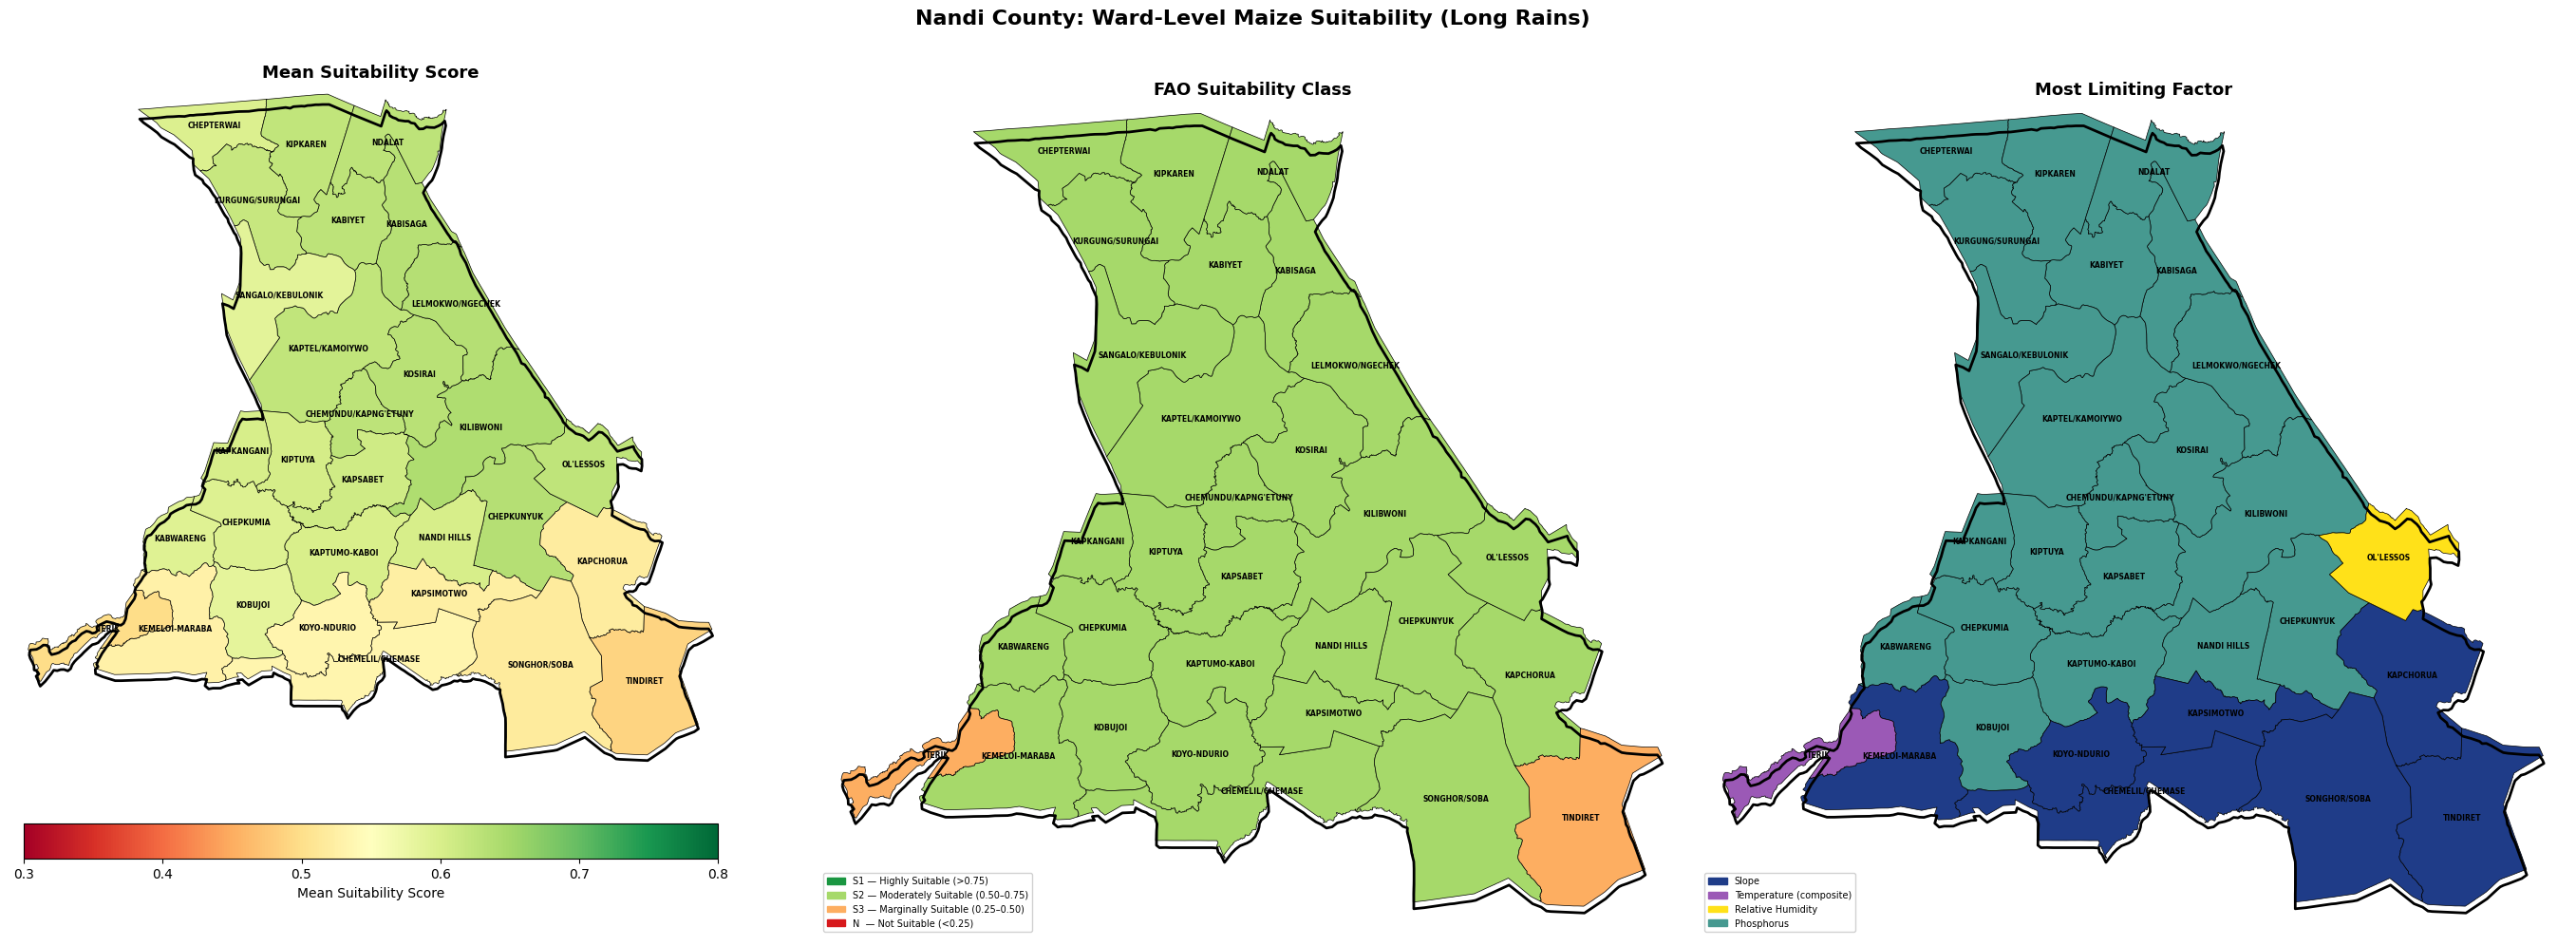

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import os

BASE        = '/content/drive/MyDrive/02_NandiSeedRecommender2'
OUT_DIR     = os.path.join(BASE, 'WardAggregatedData')
COUNTY_SHP  = os.path.join(BASE, 'NandiCounties/counties.shp')

wards  = gpd.read_file(os.path.join(OUT_DIR, 'Nandi_Ward_Aggregation.geojson'))
county = gpd.read_file(COUNTY_SHP)
nandi  = county[county['COUNTY_NAM'] == 'NANDI']

if nandi.crs != wards.crs:
    nandi = nandi.to_crs(wards.crs)

try:
    nandi_union = nandi.union_all()
except AttributeError:
    nandi_union = nandi.geometry.unary_union

nandi_wards = wards[wards.geometry.centroid.within(nandi_union)].copy()

name_col = next((c for c in nandi_wards.columns if 'NAME' in c.upper() or 'WARD' in c.upper()), None)
if name_col:
    nandi_wards = nandi_wards[~nandi_wards[name_col].str.upper().isin(['MANDA-SHIVANGA'])]

target_col = 'Main_Suit_Mean_LongRains'

def assign_class(val):
    if val > 0.75:   return 1
    elif val > 0.50: return 2
    elif val > 0.25: return 3
    else:            return 4

nandi_wards['fao_class'] = nandi_wards[target_col].apply(assign_class)

STYLE_MAP = {
    'slope':          ('#1f3c88', 'Slope'),
    'texture':        ('#a0522d', 'Soil Texture'),
    'rain':           ('#74c0e8', 'Rainfall (composite)'),
    'temp':           ('#9b59b6', 'Temperature (composite)'),
    'rh':             ('#ffe119', 'Relative Humidity'),
    'min_temp':       ('#6a0dad', 'Min Temperature'),
    'max_temp':       ('#e91e63', 'Max Temperature'),
    'germin_temp':    ('#ff6f00', 'Germination Temp'),
    'rh_dev':         ('#c8b400', 'RH Development'),
    'rh_mat':         ('#8d9400', 'RH Maturation'),
    'prec_month1':    ('#0077b6', 'Precip Month 1'),
    'prec_month2':    ('#0096c7', 'Precip Month 2'),
    'prec_month3':    ('#00b4d8', 'Precip Month 3'),
    'prec_month4':    ('#90e0ef', 'Precip Month 4'),
    'ph':             ('#e6194b', 'pH'),
    'ecec':           ('#3cb44b', 'ECEC'),
    'cec_apparent':   ('#111111', 'Apparent CEC'),
    'organic_carbon': ('#c0392b', 'Organic Carbon'),
    'total_nitrogen': ('#f58231', 'Total Nitrogen'),
    'calcium':        ('#e91e8c', 'Calcium'),
    'magnesium':      ('#556b2f', 'Magnesium'),
    'potassium':      ('#2ecc71', 'Potassium'),
    'phosphorus':     ('#469990', 'Phosphorus'),
    'zinc':           ('#4363d8', 'Zinc'),
    'iron':           ('#800000', 'Iron'),
    'stone_content':  ('#808000', 'Stone Content'),
    'bedrock_depth':  ('#aaffc3', 'Bedrock Depth'),
}

factor_cols = {
    var: f'LR_Fact_{var}_mean'
    for var in STYLE_MAP
    if f'LR_Fact_{var}_mean' in nandi_wards.columns
}

if factor_cols:
    factor_df = nandi_wards[[c for c in factor_cols.values()]].copy()
    factor_df.columns = list(factor_cols.keys())
    nandi_wards['limiting_factor'] = factor_df.idxmin(axis=1)

    present_factors = [f for f in factor_cols.keys()
                       if f in nandi_wards['limiting_factor'].values]
    factor_to_idx   = {f: i for i, f in enumerate(present_factors)}
    nandi_wards['lf_idx'] = nandi_wards['limiting_factor'].map(factor_to_idx)

    colors_used = [STYLE_MAP[f][0] for f in present_factors]
    cmap_lf     = ListedColormap(colors_used)
    norm_lf     = BoundaryNorm(range(len(present_factors) + 1), cmap_lf.N)

bounds  = nandi.total_bounds
padding = 0.02

fig, axes = plt.subplots(1, 3, figsize=(28, 10))
fig.suptitle('Nandi County: Ward-Level Maize Suitability (Long Rains)',
             fontsize=16, fontweight='bold', y=1.01)

# ---- Panel 1: Continuous score ----
nandi_wards.plot(column=target_col, ax=axes[0], cmap='RdYlGn',
                 vmin=0.3, vmax=0.8, legend=True,
                 legend_kwds={'label': "Mean Suitability Score",
                              'orientation': "horizontal", 'pad': 0.05, 'shrink': 0.8},
                 edgecolor='black', linewidth=0.5)
nandi.boundary.plot(ax=axes[0], color='black', linewidth=2)
axes[0].set_xlim(bounds[0] - padding, bounds[2] + padding)
axes[0].set_ylim(bounds[1] - padding, bounds[3] + padding)
axes[0].set_title('Mean Suitability Score', fontsize=13, fontweight='bold')
axes[0].set_axis_off()
if name_col:
    for x, y, label in zip(nandi_wards.geometry.centroid.x,
                            nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
        axes[0].text(x, y, label, fontsize=5.5, ha='center', weight='bold')

# ---- Panel 2: FAO classes ----
cmap_cls = ListedColormap(['#1a9641', '#a6d96a', '#fdae61', '#d7191c'])
norm_cls = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap_cls.N)
nandi_wards.plot(column='fao_class', ax=axes[1], cmap=cmap_cls, norm=norm_cls,
                 edgecolor='black', linewidth=0.5)
nandi.boundary.plot(ax=axes[1], color='black', linewidth=2)
axes[1].set_xlim(bounds[0] - padding, bounds[2] + padding)
axes[1].set_ylim(bounds[1] - padding, bounds[3] + padding)
axes[1].set_title('FAO Suitability Class', fontsize=13, fontweight='bold')
axes[1].set_axis_off()
fao_patches = [
    mpatches.Patch(color='#1a9641', label='S1 — Highly Suitable (>0.75)'),
    mpatches.Patch(color='#a6d96a', label='S2 — Moderately Suitable (0.50–0.75)'),
    mpatches.Patch(color='#fdae61', label='S3 — Marginally Suitable (0.25–0.50)'),
    mpatches.Patch(color='#d7191c', label='N  — Not Suitable (<0.25)'),
]
axes[1].legend(handles=fao_patches, loc='lower left', fontsize=7, framealpha=0.9)
if name_col:
    for x, y, label in zip(nandi_wards.geometry.centroid.x,
                            nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
        axes[1].text(x, y, label, fontsize=5.5, ha='center', weight='bold')

# ---- Panel 3: Most limiting factor ----
if factor_cols:
    nandi_wards.plot(column='lf_idx', ax=axes[2], cmap=cmap_lf, norm=norm_lf,
                     edgecolor='black', linewidth=0.5)
    nandi.boundary.plot(ax=axes[2], color='black', linewidth=2)
    axes[2].set_xlim(bounds[0] - padding, bounds[2] + padding)
    axes[2].set_ylim(bounds[1] - padding, bounds[3] + padding)
    axes[2].set_title('Most Limiting Factor', fontsize=13, fontweight='bold')
    axes[2].set_axis_off()
    lf_patches = [mpatches.Patch(color=STYLE_MAP[f][0], label=STYLE_MAP[f][1])
                  for f in present_factors]
    axes[2].legend(handles=lf_patches, loc='lower left', fontsize=7, framealpha=0.9)
    if name_col:
        for x, y, label in zip(nandi_wards.geometry.centroid.x,
                                nandi_wards.geometry.centroid.y, nandi_wards[name_col]):
            axes[2].text(x, y, label, fontsize=5.5, ha='center', weight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Ward_Suitability_Map_Combined.png'), dpi=300, bbox_inches='tight')
plt.show()